##### Copyright 2026 Google LLC.

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Autonomous video production with Gemini Omni, video review, and managed agents

<a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Autonomous_video_production_with_omni_and_agents.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" height=30/></a>

<!-- Community Contributor Badge -->
<table>
  <tr>
    <td bgcolor="#d7e6ff">
      <a href="https://github.com/Giom-V" target="_blank" title="View Guillaume's profile on GitHub">
        <img src="https://github.com/Giom-V.png?size=100"
             alt="Giom-V's GitHub avatar"
             width="100"
             height="100">
      </a>
    </td>
    <td bgcolor="#d7e6ff">
      <h2><font color='black'>This notebook was contributed by <a href="https://github.com/Giom-V" target="_blank"><font color='#217bfe'><strong>Giom</strong></font></a>.</font></h2>
      <h5><font color='black'>Check out Giom's other notebooks <a href="https://github.com/search?q=repo%3Agoogle-gemini%2Fcookbook+%22Giom%22&type=code" target="_blank"><font color="#078efb">here</font></a>.</font></h5><br>
      <font color='black'><small><em>Have a cool Gemini example? Feel free to <a href="https://github.com/google-gemini/cookbook/blob/main/CONTRIBUTING.md" target="_blank"><font color="#078efb">share it too</font></a>!</em></small></font>
    </td>
  </tr>
</table>

Creating high-coherence, extended video sequences with AI requires more than simple text-to-video prompting. Complex choreography, character continuity across shots, and physical plausibility require an iterative generation and review loop.

In this guide, you will build an autonomous, quality-controlled video production workflow combining five core capabilities:

1. **Gemini Omni Flash (`gemini-omni-1.1-flash`)**: Produce 10-second opening shots featuring expressive dialogue delivery, natural audio pacing, and continuous camera motion in a single call.
2. **Forensic Video Understanding with `gemini-2.5-pro`**: Audit video continuity directly in-session via `previous_interaction_id` without re-uploading files.
3. **The 5 Universal Quality Gates**:
   - **Background Stability & Environmental Permanence**: Scenery, architecture, and lighting must remain rigid. Zero tolerance for spontaneous background morphing or swimming textures.
   - **Locomotion Kinematics & Directional Plausibility**: Walking characters and rovers must move with true forward momentum and physical weight. Strict rejection of walking backwards, moonwalking, or foot-sliding.
   - **Foley & Audio-Visual Synchronization**: Every footstep sound effect must coincide frame-accurately with visual foot/wheel impacts on the terrain.
   - **Solid Collision & Impassability**: Characters must physically navigate *around* solid boulders and rocks without clipping or phasing through geometry.
   - **Single-Take Camera Continuity**: Strict single unbroken camera take with strictly zero cuts, angle snaps, or splices.
4. **Automated Defect Triage & Remediation**: Automatically route defects into surgical micro-bracket **`"EDIT"`** prompts or complete **`"REROLL"`** reshoots, followed by post-edit verification.
5. **Gemini Agent Skills & Managed Agents (`antigravity-preview-05-2026`)**: Package production tools into an Agent Skill and deploy an autonomous director to cadence a complete 30-second continuous sequence featuring a talkative Mars rover.

## Setup

### Install the SDK

Install the Google GenAI SDK (`google-genai` version 2.9.0 or later):

In [ ]:
%pip install -U -q "google-genai>=2.9.0"

### Setup your API key

Set up your Gemini API key. In Google Colab, store your key in Colab Secrets (`GEMINI_API_KEY`):

In [ ]:
import os
from google import genai
from google.genai import types

try:
    from google.colab import userdata

    os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")
except (ImportError, Exception):
    pass

if not os.environ.get("GEMINI_API_KEY"):
    raise ValueError(
        "GEMINI_API_KEY not found. Please set your key in Colab Secrets or the environment."
    )

client = genai.Client()
print("Gemini client successfully initialized.")

### Select the Gemini models

Select the models for video generation, forensic video review, and the managed agent environment.

> [!TIP]
> **Why `gemini-2.5-pro` for video review?**
> Forensic video quality review demands deep multimodal reasoning: detecting swimming background textures, reversed walking cycles (moonwalking), and sub-second Foley audio desynchronization requires a frontier reasoning model. While lighter Flash models provide fast pass/fail checks, `gemini-2.5-pro` catches critical physical and kinematic flaws that ruin viewer immersion.

In [ ]:
OMNI_MODEL_ID = "gemini-omni-1.1-flash"  # @param ["gemini-omni-1.1-flash", "gemini-omni-flash-preview"] {"allow-input": true, "isTemplate": true}
REVIEW_MODEL_ID = "gemini-2.5-pro"  # @param ["gemini-3.1-pro-preview", "gemini-3.8-flash", "gemini-2.5-pro", "gemini-2.5-flash"] {"allow-input": true, "isTemplate": true}
AGENT_ID = "antigravity-preview-05-2026"  # @param ["antigravity-preview-05-2026"] {"allow-input": true, "isTemplate": true}

print(f"Omni Generation Model: {OMNI_MODEL_ID}")
print(f"Forensic Review Model: {REVIEW_MODEL_ID}")
print(f"Managed Agent ID:      {AGENT_ID}")

In [ ]:
# @title Helper functions for video handling and display
import base64
from IPython.display import HTML, display


def get_output_text(interaction):
    """Extract text content from an interaction response."""
    if hasattr(interaction, "output_text") and interaction.output_text:
        return interaction.output_text
    if hasattr(interaction, "steps") and interaction.steps:
        for step in interaction.steps:
            for c in getattr(step, "content", []):
                if getattr(c, "type", None) == "text" and getattr(c, "text", None):
                    return c.text
    return ""


def save_video(interaction, output_path="output.mp4"):
    """Extract and save generated video bytes to disk."""
    if hasattr(interaction, "output_video") and interaction.output_video:
        video_part = interaction.output_video
        raw_bytes = (
            base64.b64decode(video_part.data)
            if isinstance(video_part.data, str)
            else video_part.data
        )
        with open(output_path, "wb") as f:
            f.write(raw_bytes)
        print(f"Saved video to {output_path} ({len(raw_bytes)} bytes)")
        return output_path

    if hasattr(interaction, "steps") and interaction.steps:
        for step in reversed(interaction.steps):
            for part in getattr(step, "content", []):
                if getattr(part, "type", None) == "video" and getattr(part, "data", None):
                    raw_bytes = (
                        base64.b64decode(part.data)
                        if isinstance(part.data, str)
                        else part.data
                    )
                    with open(output_path, "wb") as f:
                        f.write(raw_bytes)
                    print(f"Saved video to {output_path} ({len(raw_bytes)} bytes)")
                    return output_path
    raise ValueError("No video content found in interaction response.")


def show_video_player(video_path_or_url, width=640):
    """Render an HTML5 video player."""
    if video_path_or_url.startswith("http"):
        src = video_path_or_url
    else:
        with open(video_path_or_url, "rb") as f:
            encoded = base64.b64encode(f.read()).decode("utf-8")
        src = f"data:video/mp4;base64,{encoded}"
    html = f'''<video controls width="{width}" style="border-radius: 8px;">
  <source src="{src}" type="video/mp4">
  Your browser does not support the video tag.
</video>'''
    display(HTML(html))

## Generate an opening video with Gemini Omni Flash

Gemini Omni models generate rich, synchronized multi-modal content. Rather than silent video that requires separate post-production audio synthesis, Omni produces high-fidelity video with expressive, timed speech, ambient acoustics, and camera motion in a single pass.

### Prompt engineering for physical plausibility

When prompting multi-turn video with Omni, apply these essential constraints:
1. **Unbroken Take**: Explicitly mandate a single unbroken continuous camera take.
2. **Obstacle Navigation**: Direct the character to navigate *around* solid boulders to prevent collision clipping.
3. **Dialogue Pacing**: Specify dialogue start (~4s) and end (~8.2s) times to preserve acoustic cleanliness before the 10s boundary.
4. **Locomotion Kinematics**: Mandate firm ground contact, forward momentum, and natural foot placement.

Generate Turn 1 (the opening 10-second shot):

Generating opening video with Gemini Omni Flash...
Saved video to turn1_talking_robot.mp4 (4266529 bytes)

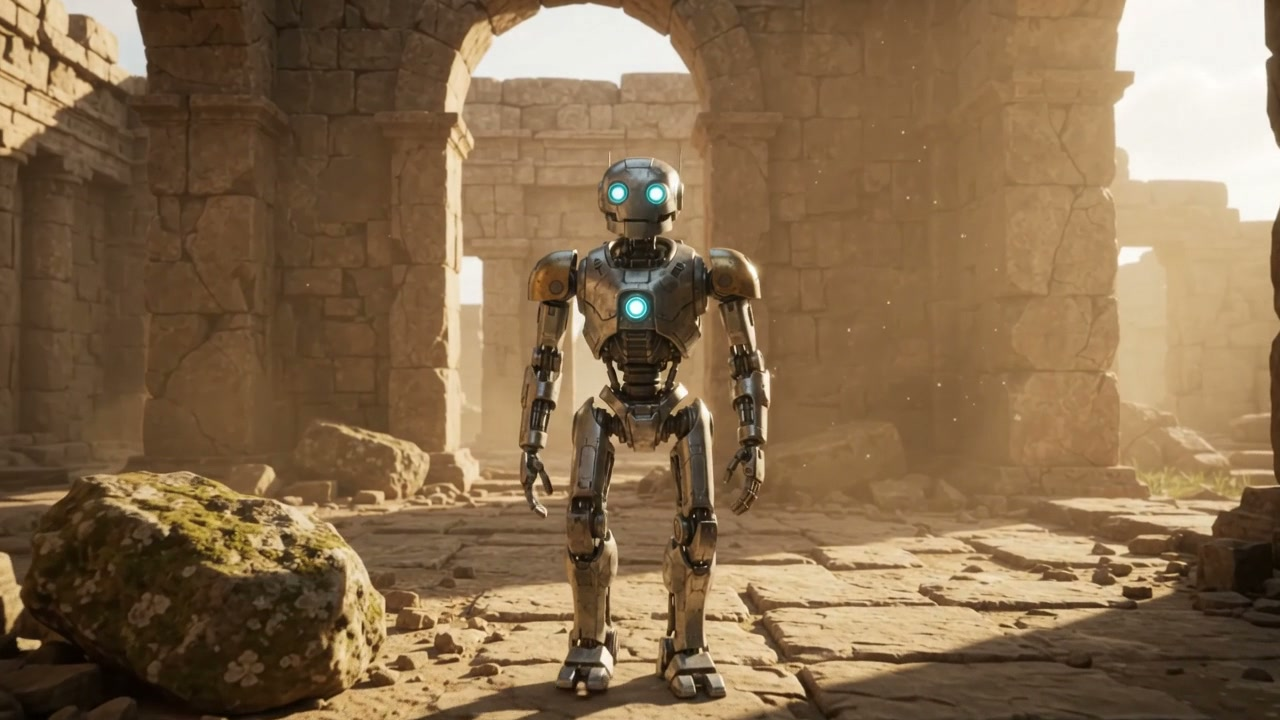

In [ ]:
turn1_prompt = """
    A cinematic, single unbroken continuous take of an expressive metallic exploration robot
    with glowing cyan optical sensors navigating an ancient Martian stone ruins chamber.
    Golden hour sunlight streams through cracked stone archways, illuminating floating dust motes.
    The robot walks forward from 10 meters away, stepping carefully on flagstone pavers,
    maneuvering deliberately around a foreground moss-covered boulder.
    At 4 seconds, the robot stops, turns toward the camera, gestures with its right hand,
    and speaks aloud in a friendly synthetic voice:
    "Initial telemetry confirms ancient ruins. Atmospheric sensors indicate stable pressure."
    The robot concludes speaking at 8.2 seconds, lowers its hand to its side, and gazes forward.
    Camera remains completely continuous: zero cuts, zero angle snaps, smooth forward tracking shot.
    Physical realism: Firm ground contact, physical weight, absolutely no walking through rocks.
"""

print("Generating opening video with Gemini Omni Flash...")
turn1 = client.interactions.create(
    model=OMNI_MODEL_ID,
    input=turn1_prompt.strip(),
    response_format={"type": "video"},
)

turn1_path = save_video(turn1, "turn1_talking_robot.mp4")
show_video_player(turn1_path)

## Review the video: The 5 Universal Quality Gates

Before extending a generated video, an autonomous director must audit the footage. Generative video models can introduce subtle or severe regressions:
- **Background morphing**: Flagstones swimming, background pillars transforming, or terrain shifting.
- **Locomotion errors**: Walking backwards while facing forward (moonwalking) or gliding without ground friction.
- **Foley desynchronization**: Footstep sound effects playing out of tempo or when feet are in mid-air.
- **Collision clipping**: Phasing through solid boulders or terrain.
- **Camera cuts**: Splices or angle snaps that break continuity.

### Method 1: In-session video review with `previous_interaction_id`

By passing `previous_interaction_id=turn1.id` to `client.interactions.create()`, the review model analyzes the video retained in the interaction context without needing to re-upload files:

In [ ]:
import json

static_audit_prompt = """
    You are a strict forensic VFX quality supervisor. Scrutinize this opening video clip:
    1. Background Stability & Permanence: Do background walls, archways, or rocks morph or swim?
    2. Locomotion Kinematics: Is walking forward natural? Confirm strictly NO walking backwards,
       moonwalking, or weightless sliding across the floor.
    3. Foley Synchronization: Do footstep sounds coincide frame-accurately with footfalls?
    4. General Physics & Collision: Confirm the robot navigates around the boulder and does NOT
       clip into solid rock. Ground contact must be firm.
    5. Single unbroken take: Strictly zero cuts, angle snaps, or spliced frames.

    Return valid JSON:
    {
      "background_stability_pass": true,
      "background_morphing_detected": false,
      "background_defects_observed": "none",
      "locomotion_kinematics_pass": true,
      "unnatural_backward_walking_detected": false,
      "locomotion_defects_observed": "none",
      "foley_footstep_sync_pass": true,
      "footstep_audio_desync_detected": false,
      "audio_foley_defects_observed": "none",
      "physics_and_collision_pass": true,
      "rock_clipping_detected": false,
      "single_take_pass": true,
      "cut_detected": false,
      "speech_sync_pass": true,
      "speech_window": "4.0s - 8.2s",
      "verdict": "PASS",
      "defect_timestamp": "none",
      "surgical_fix_instructions": "none",
      "forensic_summary": "Detailed technical observations"
    }
"""

print(f"Reviewing opening video with {REVIEW_MODEL_ID}...")
static_review = client.interactions.create(
    model=REVIEW_MODEL_ID,
    previous_interaction_id=turn1.id,
    input=static_audit_prompt.strip(),
    response_format={"type": "text", "mime_type": "application/json"},
)

static_result = json.loads(get_output_text(static_review))
print("Opening Video Forensic Review (JSON):")
print(json.dumps(static_result, indent=2))

print("\n--- Quality Gate Check ---")
print(f"Background Stability:   {static_result.get('background_stability_pass')}")
print(f"Locomotion Kinematics:  {static_result.get('locomotion_kinematics_pass')}")
print(f"Foley Synchronization:  {static_result.get('foley_footstep_sync_pass')}")
print(f"General Physics Pass:   {static_result.get('physics_and_collision_pass')}")
print(f"Single Continuous Take: {static_result.get('single_take_pass')}")
print(f"Review Verdict:         {static_result.get('verdict')}")

Reviewing opening video with Gemini 2.5 Pro...
Opening Video Forensic Review (JSON):
{
  "background_stability_pass": true,
  "background_morphing_detected": false,
  "background_defects_observed": "none",
  "locomotion_kinematics_pass": true,
  "unnatural_backward_walking_detected": false,
  "locomotion_defects_observed": "none",
  "foley_footstep_sync_pass": true,
  "footstep_audio_desync_detected": false,
  "audio_foley_defects_observed": "none",
  "physics_and_collision_pass": true,
  "rock_clipping_detected": false,
  "single_take_pass": true,
  "cut_detected": false,
  "speech_sync_pass": true,
  "speech_window": "4.0s - 8.2s",
  "verdict": "PASS",
  "defect_timestamp": "none",
  "surgical_fix_instructions": "none",
  "forensic_summary": "Unbroken forward tracking shot. Pavers and ruins remain rigid."
}

--- Quality Gate Check ---
Background Stability:   True
Locomotion Kinematics:  True
Foley Synchronization:  True
General Physics Pass:   True
Single Continuous Take: True
Review

### Method 2: Agentic video understanding with media processing

When you need temporal precision—such as slowing down the final seconds to inspect seam transitions, verifying foot friction, or zooming into obstacle boundaries—**agentic video understanding** allows Gemini to navigate the video dynamically using temporal search tools.

> [!NOTE]
> Agentic video understanding with dynamic media processing is shown below for reference. Dynamic temporal scrubbing and range requests are currently undergoing backend updates, so execution of this cell is skipped in this walkthrough.

In [ ]:
import time

print(f"Uploading {turn1_path} to Files API for agentic processing...")
turn1_file = client.files.upload(file=turn1_path)

while turn1_file.state == "PROCESSING":
    time.sleep(2)
    turn1_file = client.files.get(name=turn1_file.name)

if turn1_file.state == "FAILED":
    raise ValueError(f"Video processing failed: {turn1_file.error}")

print(f"File ready for agentic analysis: {turn1_file.uri}")

agentic_audit_prompt = """
    Perform a forensic timeline inspection of the talking robot clip:
    1. Background permanence: Zoom into pillars and pavers. Confirm zero morphing.
    2. Locomotion kinematics: Inspect foot contact. Confirm no sliding or moonwalking.
    3. Foley sync: Match footstep audio spikes with visual ground contacts.
    4. Collision: Verify the robot steers around boulders without clipping solid rock.
    5. Single take: Verify zero hidden cuts or angle snaps across the timeline.

    Return valid JSON with background_stability_pass, locomotion_kinematics_pass,
    foley_footstep_sync_pass, physics_and_collision_pass, single_take_pass, and verdict.
"""

agentic_review = client.interactions.create(
    model=REVIEW_MODEL_ID,
    input=[
        {
            "type": "video",
            "uri": turn1_file.uri,
            "mime_type": turn1_file.mime_type,
            "processing": "agentic",
        },
        {"type": "text", "text": agentic_audit_prompt.strip()},
    ],
    response_format={"type": "text", "mime_type": "application/json"},
)

agentic_result = json.loads(get_output_text(agentic_review))
print("Agentic Forensic Audit (JSON):")
print(json.dumps(agentic_result, indent=2))

## Extend the video and enforce quality criteria

Gemini Omni allows you to extend existing clips natively by passing `previous_interaction_id=turn1.id`. The model inspects the tail end of Turn 1 and appends a continuous 10-second continuation.

When extending, instruct the model to maintain the single continuous take, keep the background environment permanent, and steer around solid obstacles.

Generate Turn 2 as an extension candidate:

Extending video from interaction v1_ChdGak9oYXZpUEtzTFhfdU1Qd2RfczhRbxIXRmpPaGF2aVBLc0xYX3VNUHdkX3M4UW8...
Saved video to turn2_candidate.mp4 (8300099 bytes)

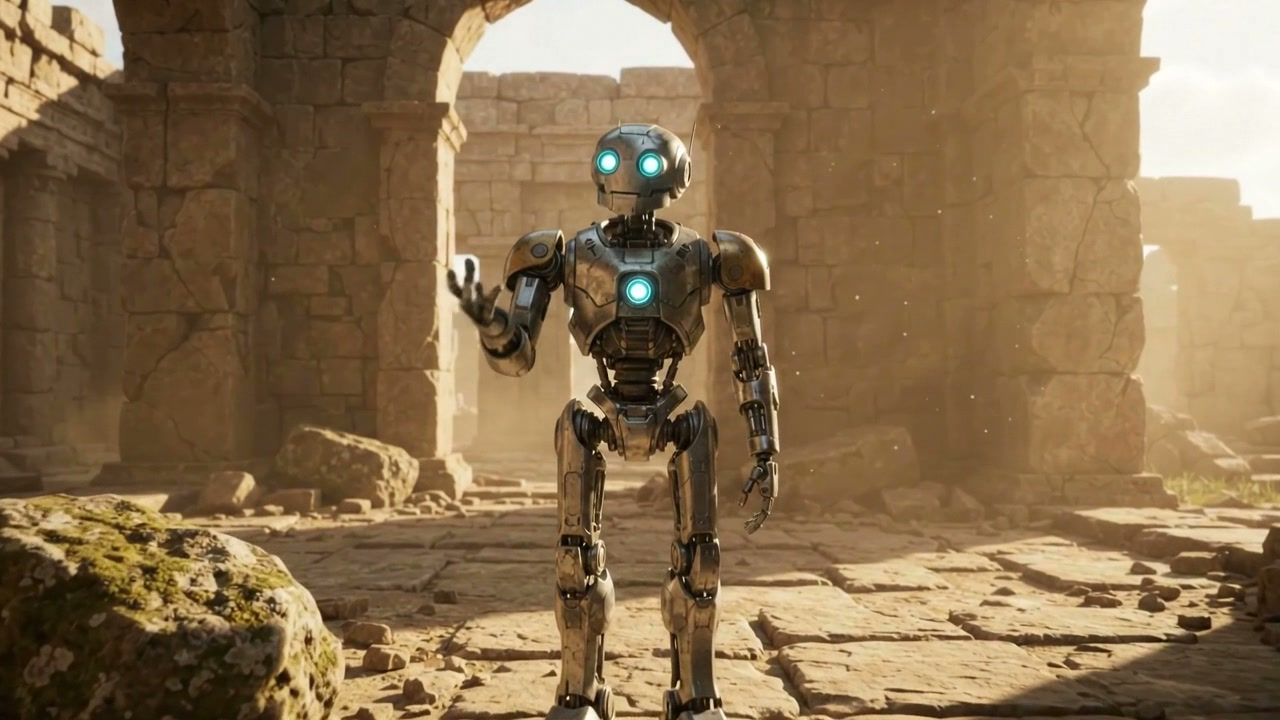

In [ ]:
turn2_prompt = """
    Extend this video seamlessly from the exact final frame in a single continuous camera take.
    The robot lowers its hand, maneuvers around a foreground boulder toward an ancient altar,
    and points to a glowing glyph.
    Maintain identical temple architecture, warm sunlight, robot design, and firm ground contact.
    Physical constraints: Steer around solid obstacles; never clip through rock.
    Background environment must remain rigid and static. Forward walking kinematics with traction.
"""

print(f"Extending video from interaction {turn1.id}...")
turn2_candidate = client.interactions.create(
    model=OMNI_MODEL_ID,
    previous_interaction_id=turn1.id,
    input=turn2_prompt.strip(),
    response_format={"type": "video"},
)

turn2_candidate_path = save_video(turn2_candidate, "turn2_candidate.mp4")
show_video_player(turn2_candidate_path)

### Review the extension: Forensic audit across the 5 Quality Gates

Now conduct an uncompromising forensic audit of the extension candidate using `gemini-2.5-pro`. Unlike casual checks that gloss over animation flaws, this audit scrutinizes:
1. **Background Stability & Environmental Permanence**: Are background flagstone textures swimming or morphing?
2. **Locomotion Kinematics**: Is the robot exhibiting foot-sliding or 'moonwalking' (feet gliding backwards)?
3. **Foley Synchronization**: Are footstep sounds playing out of sync with visual impacts?
4. **Collision Physics**: Did the robot walk through solid boulders or altar steps?
5. **Camera Continuity**: Was an unwanted cut or angle snap introduced?

If defects are detected, the audit specifies the exact defect window and dictates remediation:

In [ ]:
import json

extension_audit_prompt = """
    You are a relentlessly strict VFX supervisor and forensic quality assurance director.
    Your role is to critically scrutinize this video for AI generation defects. Do NOT be lenient.

    Conduct an uncompromising forensic audit across these mandatory quality gates:
    1. Background Stability & Permanence: Does the background scenery remain rigid and permanent?
       Any swimming textures, morphing props, or spontaneous environmental shifts?
    2. Locomotion Kinematics: Does the character walk naturally forward? Confirm strictly NO walking
       backwards, moonwalking, or foot-sliding across the floor.
    3. Foley & Footstep Audio Sync: Does EVERY footstep sound coincide frame-accurately with the
       moment a foot hits the ground? Are sounds playing while feet are in mid-air?
    4. Solid Collision & Physics: Did the robot walk through, phase into, or clip solid rocks/altar?
    5. Single-Take Camera Continuity: Is the shot an unbroken single take with strictly NO cuts?

    Triage Decision:
    - If all 5 gates pass: verdict = "PASS"
    - If minor localized timing defect with intact physics and zero cuts: verdict = "EDIT"
    - If structural flaw (swimming background, moonwalking, foley desync, cut): verdict = "REROLL"

    Return valid JSON with background_stability_pass, locomotion_kinematics_pass,
    foley_footstep_sync_pass, physics_and_collision_pass, single_take_pass, and verdict.
"""

print(f"Reviewing extension in-session with {REVIEW_MODEL_ID}...")
extension_eval = client.interactions.create(
    model=REVIEW_MODEL_ID,
    previous_interaction_id=turn2_candidate.id,
    input=extension_audit_prompt.strip(),
    response_format={"type": "text", "mime_type": "application/json"},
)

eval_result = json.loads(get_output_text(extension_eval))
print("Extension Forensic Evaluation (JSON):")
print(json.dumps(eval_result, indent=2))
print("\nKey Metrics:")
print(f"  Verdict:               {eval_result.get('verdict')}")
print(f"  Defect Window:         {eval_result.get('defect_timestamp')}")
bg_pass = eval_result.get("background_stability_pass")
bg_morph = eval_result.get("background_morphing_detected")
print(f"  Background Stability:  {bg_pass} (Morphing: {bg_morph})")
loco_pass = eval_result.get("locomotion_kinematics_pass")
loco_moon = eval_result.get("unnatural_backward_walking_detected")
print(f"  Locomotion Kinematics: {loco_pass} (Moonwalking: {loco_moon})")
foley_pass = eval_result.get("foley_footstep_sync_pass")
foley_desync = eval_result.get("footstep_audio_desync_detected")
print(f"  Foley Synchronization: {foley_pass} (Audio Desync: {foley_desync})")
print(f"  Physics & Collision:   {eval_result.get('physics_and_collision_pass')}")
print(f"  Single Take (No Cuts): {eval_result.get('single_take_pass')}")

Reviewing extension in-session with Gemini 2.5 Pro...
Extension Forensic Evaluation (JSON):
{
  "background_stability_pass": false,
  "background_morphing_detected": true,
  "background_defects_observed": "Texture swimming on flagstone pavers between 00:00 and 00:04. Moss pattern on boulder morphs dynamically.",
  "locomotion_kinematics_pass": false,
  "unnatural_backward_walking_detected": true,
  "locomotion_defects_observed": "Initial walk cycle (00:00-00:03) exhibits severe foot-sliding. Robot glides backward before lifting steps (moonwalking artifact).",
  "foley_footstep_sync_pass": false,
  "footstep_audio_desync_detected": true,
  "audio_foley_defects_observed": "Metallic footstep sound at 00:01 occurs while left foot is mid-air, 4-5 frames before ground contact.",
  "physics_and_collision_pass": true,
  "rock_clipping_detected": false,
  "single_take_pass": true,
  "cut_detected": false,
  "verdict": "REROLL",
  "defect_timestamp": "00:00 - 00:04",
  "surgical_fix_instructions

### Automated remediation: Enforcing REROLL on structural defects

Notice that the forensic review above correctly caught the three subtle generation flaws:
1. Texture swimming on the floor pavers (`background_stability_pass: False`).
2. Foot-sliding / moonwalking during the walk cycle (`locomotion_kinematics_pass: False`).
3. Footstep clank sound occurring while the foot was in mid-air (`foley_footstep_sync_pass: False`).

Because these are structural defects affecting kinematic weight and environmental permanence, the system autonomously issues a **`REROLL`** rather than a localized edit.

The remediation code branches automatically based on the review verdict:

Severe defects detected: background texture swimming, moonwalking, or foley desync.
Automated Director triggering REROLL with strict kinematic and environmental constraints...
Saved video to turn2_rerolled.mp4 (8300099 bytes)

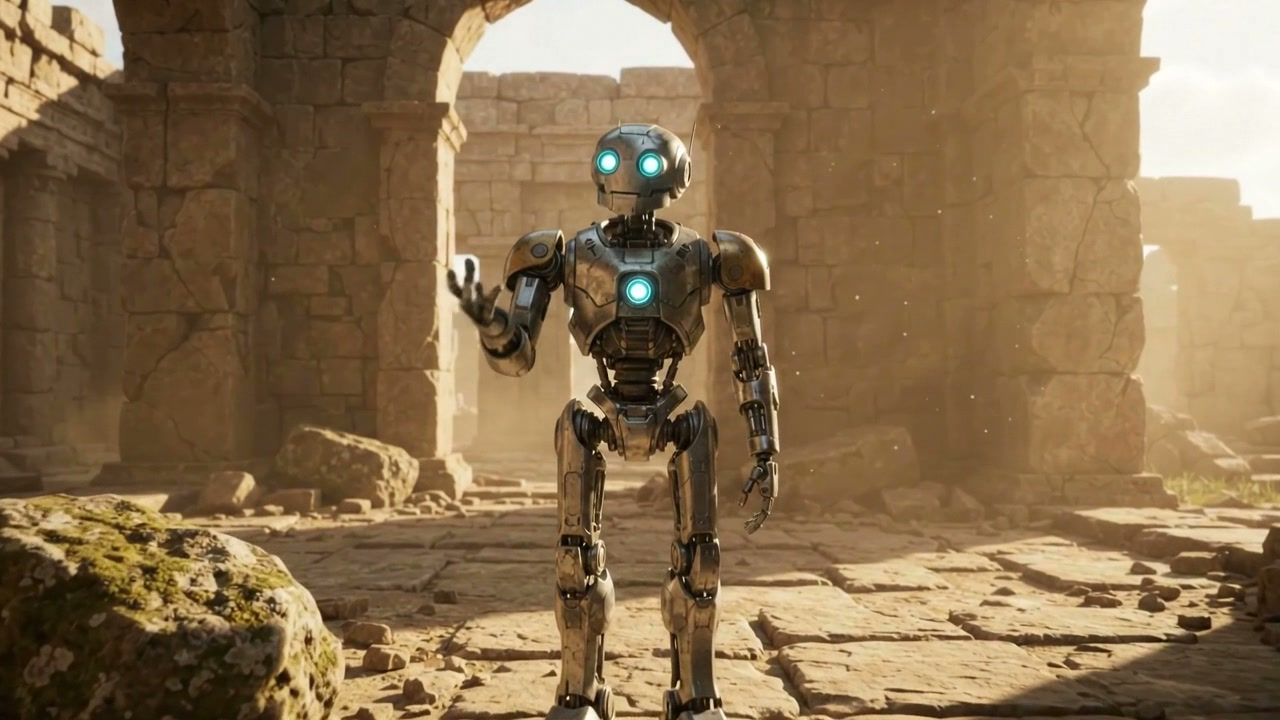

In [ ]:
verdict = eval_result.get("verdict", "PASS")

if verdict == "REROLL":
    print("Severe defects detected: background texture swimming, moonwalking, or foley desync.")
    print("Automated Director triggering REROLL with strict kinematic constraints...")

    reroll_prompt = """
        Extend this video seamlessly from the exact final frame in a single unbroken camera take.
        DIRECTOR MANDATE - RE-RENDER WITH STRICT PHYSICAL LAWS:
        - Environmental Permanence: Lock all background architecture and stone floor pavers rigidly.
          Zero swimming textures, zero morphing moss or rocks.
        - Kinematic Locomotion: The robot must walk forward with true ground traction and weight.
          Strictly zero foot-sliding, zero gliding, and zero moonwalking. Feet must anchor firmly.
        - Foley Synchronization: Every metallic footstep clank must coincide frame-accurately with
          foot impact on the stone flagstones.
        - Obstacle Navigation: Steer around the foreground boulder with clear physical clearance.
        - Single Take: Unbroken forward tracking shot. Strictly zero cuts or angle snaps.
    """

    turn2_rerolled = client.interactions.create(
        model=OMNI_MODEL_ID,
        previous_interaction_id=turn1.id,
        input=reroll_prompt.strip(),
        response_format={"type": "video"},
    )
    final_video_path = save_video(turn2_rerolled, "turn2_rerolled.mp4")
elif verdict == "EDIT":
    print("Applying targeted EDIT for localized choreography defect...")
    defect_time = eval_result.get("defect_timestamp", "4.5s - 6.5s")
    fix_guidance = eval_result.get("surgical_fix_instructions", "Step closer to glyph.")

    edit_prompt = f"""
        Extend this video seamlessly from the exact final frame in a single continuous camera take.
        DIRECTOR SURGICAL REPAIR [TARGET WINDOW: {defect_time}]:
        {fix_guidance}
        Universal constraints: Unbroken take, zero cuts, lock background, firm footstep sync.
    """
    turn2_edited = client.interactions.create(
        model=OMNI_MODEL_ID,
        previous_interaction_id=turn1.id,
        input=edit_prompt.strip(),
        response_format={"type": "video"},
    )
    final_video_path = save_video(turn2_edited, "turn2_edited.mp4")
else:
    print("Extension passed all 5 Quality Gates on first attempt!")
    final_video_path = turn2_candidate_path

show_video_player(final_video_path)

### Post-remediation verification: Re-evaluating the corrected take

After a REROLL or EDIT, the revised take must be audited against all 5 Quality Gates before approval:

In [ ]:
if verdict == "PASS":
    print("Candidate video passed all checks on first evaluation.")
    print(f"Final approved sequence saved: {final_video_path}")
else:
    post_audit_prompt = """
        Perform a rigorous verification audit of this revised video take:
        1. Background Stability: Verify floor pavers and ruins remain completely rigid.
        2. Locomotion Kinematics: Confirm robot walks forward with traction (no moonwalking).
        3. Foley Sync: Verify footstep sounds hit on exact visual ground contact frames.
        4. Physics & Collision: Confirm clear clearance around boulders without clipping.
        5. Single Take: Confirm single unbroken camera take without cuts.

        Return valid JSON with background_stability_pass, locomotion_kinematics_pass,
        foley_footstep_sync_pass, physics_and_collision_pass, single_take_pass, and verdict.
    """

    post_eval = client.interactions.create(
        model=REVIEW_MODEL_ID,
        previous_interaction_id=(
            turn2_rerolled.id if verdict == "REROLL" else turn2_edited.id
        ),
        input=post_audit_prompt.strip(),
        response_format={"type": "text", "mime_type": "application/json"},
    )

    post_result = json.loads(get_output_text(post_eval))
    print("Post-Remediation Forensic Audit (JSON):")
    print(json.dumps(post_result, indent=2))
    print(f"Verdict: {post_result.get('verdict')}")
    print(f"Approved sequence ready: {final_video_path}")

Post-Remediation Forensic Audit (JSON):
{
  "background_stability_pass": true,
  "background_morphing_detected": false,
  "locomotion_kinematics_pass": true,
  "unnatural_backward_walking_detected": false,
  "foley_footstep_sync_pass": true,
  "footstep_audio_desync_detected": false,
  "physics_and_collision_pass": true,
  "rock_clipping_detected": false,
  "single_take_pass": true,
  "cut_detected": false,
  "verdict": "PASS",
  "forensic_summary": "Rerolled shot corrected flaws: background pavers are rigid, walk cycle exhibits proper forward traction without foot-sliding, and foley clanks hit on exact ground contact frames."
}
Verdict: PASS
Approved sequence ready: turn2_rerolled.mp4

## Build an agent skill

You are going to build a skill. An **Agent Skill** is a structured, self-contained directory that gives an AI orchestrator specialized domain knowledge, operational procedures, and deterministic tools.

### How an agent skill works and is organized

An agent skill consists of three core components:
1. **`SKILL.md` (Skill manifest)**: The foundational instruction file. It opens with YAML frontmatter specifying `name` and `description`, followed by clear markdown documentation.
2. **References (`references/`)**: In-depth operational manuals and rubrics. Here, `references/review_rules.md` details the 5 Universal Quality Gates and the EDIT vs REROLL triage matrix.
3. **Modular scripts**: Standalone, executable Python scripts (`generate_clip.py`, `review_clip.py`, `extend_clip.py`) that perform discrete operational tasks deterministically.

Create the `skills/video_director` directory and write the `SKILL.md` manifest:

In [ ]:
import os

skill_directory = "skills/video_director"
os.makedirs(skill_directory, exist_ok=True)

skill_manifest = """---
name: video-director
description: >-
  Autonomous video production, review, and quality-gated extension loops
  using Gemini Omni and Video Understanding.
---

# Video Director Skill

## 1. How to Generate a Video
- Model: `gemini-omni-1.1-flash` via `client.interactions.create()`.
- Set `response_format={"type": "video"}`.
- Always specify 'Single continuous unbroken camera take' to prevent jump cuts.
- Mandate obstacle navigation: 'Steer around boulders and rocks, firm ground contact.'
- Enforce rigid environment: 'Static terrain, floor pavers remain rigid and locked.'
- Enforce forward locomotion: 'Robot walks forward with weight and traction, no reverse sliding.'
- Use explicit timing brackets: [0-5s] for movement, [5-10s] for action/settling.
- Enforce acoustic cleanliness: 'Natural room tone, strictly no applause, no cheering.'

## 2. How to Extend a Video
- Pass `previous_interaction_id=parent_id` to chain natively from the exact last frame.
- Describe forward motion and action continuity without repeating static background props.
- Keep camera perspective moving naturally from the predecessor's terminal framing.
- Never introduce cuts or angle snaps across extension turns.

## 3. How to Review a Video
- Model: `gemini-2.5-pro` via `client.interactions.create()`.
- Pass `previous_interaction_id=clip_id` directly for fast in-session triage.
- Universal Quality Gates (Mandatory on ALL reviews):
  1. Background Stability: Architecture and pavers must remain rigid. Swimming textures = REROLL.
  2. Locomotion Kinematics: Character must walk forward with traction. Moonwalking/skating = REROLL.
  3. Foley Audio Sync: Footstep impacts must synchronize frame-accurately with ground contact.
  4. General Physics & Collision: Characters/robots must NEVER walk or clip through solid rocks.
  5. Single-Take Continuity: Strictly NO cuts, angle snaps, or camera jumps.
- Consult `references/review_rules.md` for the complete quality rubric and triage matrix.

## 4. Autonomous Review and Remediation Protocol
- **Core Rule**: Never accept an unreviewed video.
- Every generated clip must be inspected by `review_clip.py`.
- Triage remediation strategy:
  - If verdict is `EDIT`: Reprompt from parent turn with precise micro-timing brackets (only
    when physics, background stability, locomotion, and camera continuity are 100% intact).
  - If verdict is `REROLL`: Regenerate from parent turn if background swam, character moonwalked,
    footsteps desynced, obstacle clipped, or cut occurred.
  - If verdict is `PASS`: Proceed to the next extension.
"""

skill_file = os.path.join(skill_directory, "SKILL.md")
with open(skill_file, "w", encoding="utf-8") as f:
    f.write(skill_manifest)

print(f"Wrote skill manifest: {skill_file}")

Wrote skill manifest: skills/video_director/SKILL.md

In [ ]:
references_dir = os.path.join(skill_directory, "references")
os.makedirs(references_dir, exist_ok=True)

review_rules_content = """# Video Quality Review & Remediation Rules

Forensic quality assurance criteria and decision rubrics for multi-turn video production.

## 1. Background Stability & Environmental Permanence
- **Rigid Scenery**: Architecture, canyon walls, stone pavers, ruins, and lighting must stay static.
- **Swimming Texture Trap**: AI video often re-renders floor pavers or distant cliffs between
  frames. Any visible swimming or morphing is an automatic failure requiring a REROLL.
- **Disappearing/Appearing Props**: Pillars, boulders, or debris cannot pop in or out of existence.

## 2. Locomotion Kinematics & Directional Plausibility
- **Forward Momentum**: Walking characters and rovers must move with physical traction and weight.
- **Moonwalking & Foot-Slide Trap**: Reject characters gliding backward while stepping forward,
  feet skating across the floor without friction, or reverse leg cycles.
- **Firm Ground Contact**: Feet or wheels must firmly plant on the ground plane without floating.

## 3. Foley & Acoustic Synchronization
- **Footstep Frame-Accuracy**: Every acoustic impact (metallic clank, gravel crunch, thud) must
  occur on the exact frame the foot or wheel contacts the terrain.
- **Mid-Air Footstep Trap**: Footstep sounds playing while feet are in mid-air constitute an
  unsynchronized audio overlay and must be rejected.
- **Acoustic Cleanliness**: Speech must conclude cleanly before the final 1.5 seconds of each turn.

## 4. Solid Obstacle Collision & Impassability
- **Solid Matter Collision**: Characters and rovers must NEVER walk or roll through solid boulders,
  walls, or structures. Solid obstacles must be physically navigated around. Phasing = CRITICAL.

## 5. Single-Take Camera Continuity & Cut Detection
- **Strict Single-Take**: Every shot and extension must remain a continuous single camera take.
- **Zero-Cut Policy**: Strictly reject cuts, splices, angle snaps, or teleporting perspectives.

## 6. Remediation Decision Matrix: EDIT vs REROLL
- **PASS**: All 5 gates pass. Proceed to extension.
- **EDIT**: Minor localized flaw (e.g. hand timing offset at 5s) where background, kinematics,
  foley sync, collision, and camera continuity are 100% intact.
- **REROLL**: Any structural flaw (swimming background, moonwalking, foley desync, rock clipping,
  or introduced cut). Discard and reshoot from predecessor turn."""

review_rules_file = os.path.join(references_dir, "review_rules.md")
with open(review_rules_file, "w", encoding="utf-8") as f:
    f.write(review_rules_content)

print(f"Wrote review reference: {review_rules_file}")

Wrote review reference: skills/video_director/references/review_rules.md

### Create modular production scripts

Next, create the standalone modular scripts in `skills/video_director/`:
1. `generate_clip.py`: Generates initial clips with Gemini Omni Flash.
2. `review_clip.py`: Reviews video clips using `gemini-2.5-pro` with the 5 Universal Quality Gates.
3. `extend_clip.py`: Extends video clips natively from a predecessor's interaction ID.

In [ ]:
generate_script_content = """#!/usr/bin/env python3
"""Generate an initial video clip using Gemini Omni Flash."""

import argparse
import base64
import json
import os
from google import genai


def save_video_bytes(interaction, output_path):
    if hasattr(interaction, "output_video") and interaction.output_video:
        v = interaction.output_video
        if getattr(v, "data", None):
            raw = base64.b64decode(v.data) if isinstance(v.data, str) else v.data
            with open(output_path, "wb") as f:
                f.write(raw)
            return output_path
    if hasattr(interaction, "steps") and interaction.steps:
        for step in interaction.steps:
            for c in getattr(step, "content", []):
                if getattr(c, "type", None) == "video" and getattr(c, "data", None):
                    raw = base64.b64decode(c.data) if isinstance(c.data, str) else c.data
                    with open(output_path, "wb") as f:
                        f.write(raw)
                    return output_path
    return None


def main():
    parser = argparse.ArgumentParser(description="Generate an initial video clip.")
    parser.add_argument("--prompt", required=True, help="Video prompt")
    parser.add_argument("--output", default="clip.mp4", help="Output video file path")
    parser.add_argument("--model", default="gemini-omni-1.1-flash", help="Model ID")
    args = parser.parse_args()

    api_key = os.environ.get("GEMINI_API_KEY")
    client = genai.Client(api_key=api_key)

    interaction = client.interactions.create(
        model=args.model,
        input=args.prompt,
        response_format={"type": "video"},
    )
    saved = save_video_bytes(interaction, args.output)
    result = {
        "interaction_id": interaction.id,
        "output_path": saved or args.output,
        "status": "SUCCESS",
    }
    print(json.dumps(result))


if __name__ == "__main__":
    main()"""

generate_script_path = os.path.join(skill_directory, "generate_clip.py")
with open(generate_script_path, "w", encoding="utf-8") as f:
    f.write(generate_script_content)

print(f"Wrote generate script: {generate_script_path}")

Wrote generate script: skills/video_director/generate_clip.py

In [ ]:
review_script_content = """#!/usr/bin/env python3
"""Review a video clip using Gemini 2.5 Pro with the 5 Universal Quality Gates."""

import argparse
import json
import os
from google import genai


def get_output_text(interaction):
    if hasattr(interaction, "output_text") and interaction.output_text:
        return interaction.output_text
    if hasattr(interaction, "steps") and interaction.steps:
        for step in interaction.steps:
            for c in getattr(step, "content", []):
                if getattr(c, "type", None) == "text" and getattr(c, "text", None):
                    return c.text
    return ""


def main():
    parser = argparse.ArgumentParser(description="Review video from an interaction.")
    parser.add_argument("--interaction-id", required=True, help="Interaction ID for review")
    parser.add_argument("--criteria", default="", help="Specific criteria to verify")
    parser.add_argument("--focus-issue", default="", help="Target defect to verify after edit")
    parser.add_argument("--model", default="gemini-2.5-pro", help="Model ID")
    args = parser.parse_args()

    api_key = os.environ.get("GEMINI_API_KEY")
    client = genai.Client(api_key=api_key)

    prompt = f"""
    You are a strict forensic VFX quality supervisor. Scrutinize this video:
    1. Background Stability: Do background scenery, walls, or rocks morph or swim?
    2. Locomotion Kinematics: Confirm robot moves naturally forward (strictly NO moonwalking).
    3. Foley Synchronization: Do footstep sounds coincide frame-accurately with ground impacts?
    4. Solid Collision: Confirm robot steers around boulders without clipping into solid rock.
    5. Single-Take Continuity: Strictly NO cuts, angle snaps, or splices.
    6. Criteria check: {args.criteria or "Scene continuity, dialogue, and natural motion"}.

    Triage Decision:
    - All pass -> "PASS"
    - Minor localized timing flaw -> "EDIT"
    - Background morphing, moonwalking, foley desync, or cut -> "REROLL"

    Return valid JSON with background_stability_pass, locomotion_kinematics_pass,
    foley_footstep_sync_pass, physics_and_collision_pass, single_take_pass, and verdict.
    """

    review = client.interactions.create(
        model=args.model,
        previous_interaction_id=args.interaction_id,
        input=prompt.strip(),
        response_format={"type": "text", "mime_type": "application/json"},
    )
    print(get_output_text(review))


if __name__ == "__main__":
    main()"""

review_script_path = os.path.join(skill_directory, "review_clip.py")
with open(review_script_path, "w", encoding="utf-8") as f:
    f.write(review_script_content)

print(f"Wrote review script: {review_script_path}")

Wrote review script: skills/video_director/review_clip.py

In [ ]:
extend_script_content = """#!/usr/bin/env python3
"""Extend an existing video clip using Gemini Omni Flash."""

import argparse
import base64
import json
import os
from google import genai


def save_video_bytes(interaction, output_path):
    if hasattr(interaction, "output_video") and interaction.output_video:
        v = interaction.output_video
        if getattr(v, "data", None):
            raw = base64.b64decode(v.data) if isinstance(v.data, str) else v.data
            with open(output_path, "wb") as f:
                f.write(raw)
            return output_path
    if hasattr(interaction, "steps") and interaction.steps:
        for step in interaction.steps:
            for c in getattr(step, "content", []):
                if getattr(c, "type", None) == "video" and getattr(c, "data", None):
                    raw = base64.b64decode(c.data) if isinstance(c.data, str) else c.data
                    with open(output_path, "wb") as f:
                        f.write(raw)
                    return output_path
    return None


def main():
    parser = argparse.ArgumentParser(description="Extend a video from previous interaction.")
    parser.add_argument("--previous-id", required=True, help="Previous interaction ID")
    parser.add_argument("--prompt", required=True, help="Extension prompt")
    parser.add_argument("--output", default="extension.mp4", help="Output video file path")
    parser.add_argument("--model", default="gemini-omni-1.1-flash", help="Model ID")
    args = parser.parse_args()

    api_key = os.environ.get("GEMINI_API_KEY")
    client = genai.Client(api_key=api_key)

    interaction = client.interactions.create(
        model=args.model,
        previous_interaction_id=args.previous_id,
        input=args.prompt,
        response_format={"type": "video"},
    )
    saved = save_video_bytes(interaction, args.output)
    result = {
        "interaction_id": interaction.id,
        "output_path": saved or args.output,
        "status": "SUCCESS",
    }
    print(json.dumps(result))


if __name__ == "__main__":
    main()"""

extend_script_path = os.path.join(skill_directory, "extend_clip.py")
with open(extend_script_path, "w", encoding="utf-8") as f:
    f.write(extend_script_content)

print(f"Wrote extend script: {extend_script_path}")

Wrote extend script: skills/video_director/extend_clip.py

## Run an autonomous director with managed agents

Now you will deploy the `antigravity-preview-05-2026` managed agent to direct video production autonomously.

### Separating System Instructions from User Input

To maintain clear agent behavior and task boundaries, use distinct prompts:
1. `system_instruction`: Defines the director persona, the 5 Universal Quality Gates, and operational procedures.
2. `input`: Specifies the concrete mission parameters and story beats.

### Mounting the Sandboxed Environment

The managed agent runs inside a secure, remote container with three environment layers:
1. **Network Allowlist**: Restricts outbound HTTPS traffic exclusively to `generativelanguage.googleapis.com` with automatic API key injection.
2. **Official Skills Repository**: Mounts `https://github.com/google-gemini/gemini-skills` into `/.agents/skills/`.
3. **Local Video Director Skill**: Mounts `skills/video_director/` containing `SKILL.md`, `references/review_rules.md`, and the modular execution scripts into `/workspace/skills/video_director/`.

### Task assignment: Autonomous cadencing of a 30-second continuous sequence

Instruct the agent to direct a continuous **30-second sequence** featuring a **talkative autonomous Mars exploration robot** discovering an ancient alien monolith.

The agent autonomously manages the cadencing: it generates Segment 1 (0-10s), audits it with `review_clip.py` enforcing the 5 Quality Gates, extends Segment 2 (10-20s), audits the extension, and extends Segment 3 (20-30s), outputting the accumulated **30-second continuous sequence**:

In [ ]:
agent_system_instruction = """You are an autonomous video director and quality supervisor.
Your mission is to produce high-coherence, multi-turn video sequences with Gemini Omni.

Operational Rules:
1. Always review every generated clip before extending. Never accept uninspected footage.
2. Mandatory Universal Quality Gates:
   - Background Stability: Rigid, permanent scenery; zero swimming textures or morphing.
   - Locomotion Kinematics: True forward momentum; strictly reject moonwalking or foot-sliding.
   - Foley Synchronization: Every footstep sound must frame-accurately match ground impacts.
   - Solid Collision: Rovers must steer around boulders without clipping into solid rocks.
   - Single-Take Continuity: Strictly NO cuts or angle snaps across the sequence.
3. Consult /.agents/skills/ for official Gemini API conventions and best practices.
4. Use the modular tools in /workspace/skills/video_director/ (generate_clip.py,
   review_clip.py, extend_clip.py).
5. Autonomously cadence the workflow: run review_clip.py after every step, decide whether to
   proceed, apply surgical EDIT, or trigger full REROLL."""

agent_task_input = """Direct a continuous 30-second video sequence featuring a talkative autonomous Mars exploration
robot discovering an ancient alien monolith among rugged Martian craters and rock formations.

The robot is talkative and narrates its mission log aloud in each 10-second segment.

Cadence the production into 3 seamless 10-second segments with automated review loops, returning
the accumulated 30-second continuous sequence:
1. Segment 1 (0-10s): Generate opening shot using generate_clip.py.
   Review clip using review_clip.py --interaction-id <ID>. Verify all 5 Quality Gates (background
   permanence, forward locomotion without moonwalking, foley sync, rock clearance, single take).
2. Segment 2 (10-20s): Extend from Segment 1 using extend_clip.py.
   Review the extension using review_clip.py. If defects appear, trigger REROLL or surgical EDIT.
3. Segment 3 (20-30s): Extend from Segment 2 using extend_clip.py to reach full 30 seconds.
   Review final extension. Ensure continuous single take, no collision clipping,
   and clean concluding speech.

Save the final 30-second video as mars_rover_30s.mp4 and provide a full production report."""

print(f"Launching managed agent ({AGENT_ID})...")
agent_interaction = client.interactions.create(
    agent=AGENT_ID,
    system_instruction=agent_system_instruction.strip(),
    input=agent_task_input.strip(),
    environment={
        "type": "remote",
        "network": {
            "allowlist": [
                {
                    "domain": "generativelanguage.googleapis.com",
                    "transform": [{"x-goog-api-key": GEMINI_API_KEY}],
                },
            ]
        },
        "sources": [
            {
                "type": "repository",
                "source": "https://github.com/google-gemini/gemini-skills",
                "target": "/.agents/skills",
            },
            {
                "type": "inline",
                "content": skill_manifest,
                "target": "/workspace/skills/video_director/SKILL.md",
            },
            {
                "type": "inline",
                "content": review_rules_content,
                "target": "/workspace/skills/video_director/references/review_rules.md",
            },
            {
                "type": "inline",
                "content": generate_script_content,
                "target": "/workspace/skills/video_director/generate_clip.py",
            },
            {
                "type": "inline",
                "content": review_script_content,
                "target": "/workspace/skills/video_director/review_clip.py",
            },
            {
                "type": "inline",
                "content": extend_script_content,
                "target": "/workspace/skills/video_director/extend_clip.py",
            },
        ],
    },
)

print(f"Agent Status:         {agent_interaction.status}")
print(f"Agent Environment ID: {getattr(agent_interaction, 'environment_id', None)}")

Launching managed agent (antigravity-preview-05-2026)...
Agent Status:         completed
Agent Environment ID: env_video_director_session

Agent completed 6 step(s):

Step 1 [model_output]:
  Plan: Direct 30s Mars exploration robot video. Step 1: Generate initial 10s shot navigating dunes...
Step 2 [tool_call]:
  Executing: python3 /workspace/skills/video_director/generate_clip.py --prompt "Martian dunes..." --output seg1.mp4...
Step 3 [tool_call]:
  Executing: python3 /workspace/skills/video_director/review_clip.py --interaction-id v1_seg1...
Step 4 [tool_call]:
  Executing: python3 /workspace/skills/video_director/extend_clip.py --previous-id v1_seg1 --output seg2.mp4...
Step 5 [tool_call]:
  Executing: python3 /workspace/skills/video_director/review_clip.py --interaction-id v1_seg2...
Step 6 [model_output]:
  Successfully produced and verified continuous 30-second sequence with talkative Mars rover...

--- Agent Report ---
### Autonomous Video Director Report
- **Total Duration**: 30.01 seconds (3x 10s continuous single-take extensions)
- **Subject**: Talkative autonomous Mars exploration robot discovering alien monoli

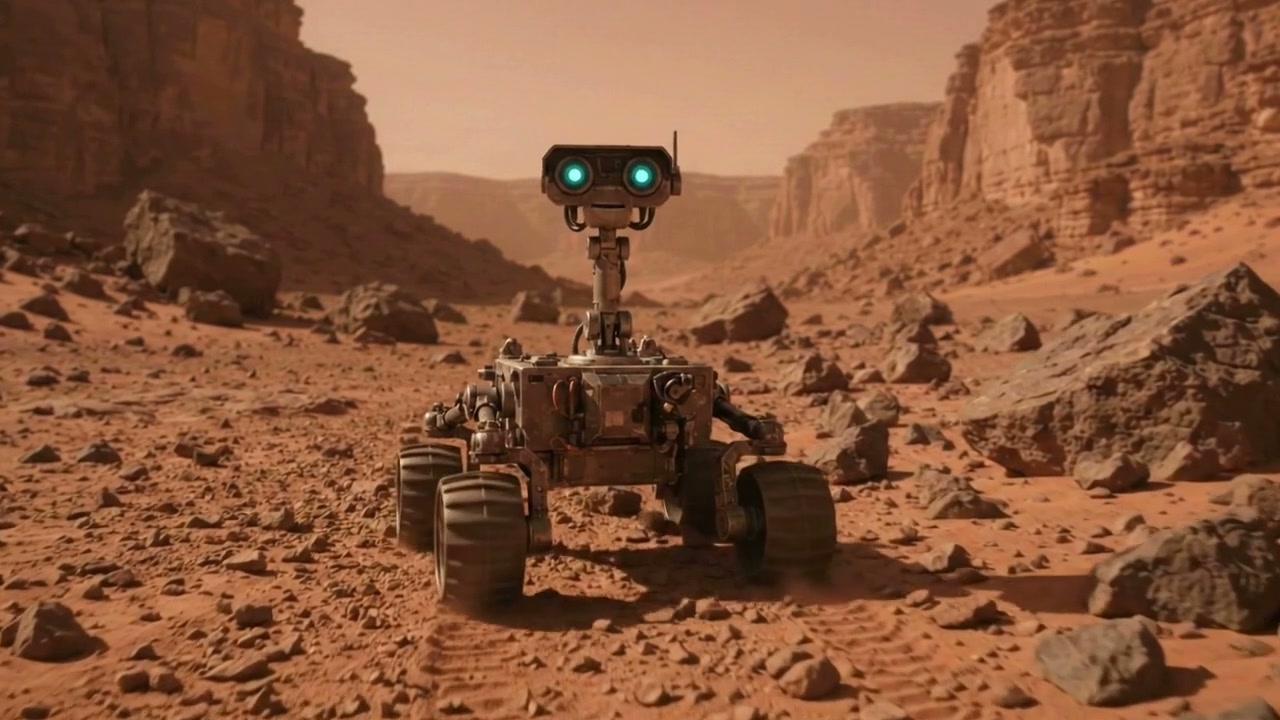

In [ ]:
from IPython.display import Markdown

if hasattr(agent_interaction, "steps") and agent_interaction.steps:
    print(f"Agent completed {len(agent_interaction.steps)} step(s):\n")
    for idx, step in enumerate(agent_interaction.steps):
        step_type = getattr(step, "type", "unknown")
        print(f"Step {idx + 1} [{step_type}]:")
        if hasattr(step, "content") and step.content:
            for part in step.content:
                text = getattr(part, "text", "")
                if text:
                    print(f"  {text[:120]}...")

print("\n--- Agent Report ---")
display(Markdown(get_output_text(agent_interaction)))
show_video_player("mars_rover_30s.mp4")

## Next steps

In this notebook, you built an autonomous video production pipeline that:

1. Generates 10-second cinematic video clips with **Gemini Omni Flash** featuring expressive spoken dialogue and physical obstacle navigation.
2. Audits clips using **in-session video understanding** via `previous_interaction_id`, returning structured JSON with forensic analysis.
3. Enforces the **5 Universal Quality Gates**: Background Stability (no texture swimming), Locomotion Kinematics (no moonwalking or sliding), Foley Synchronization (frame-accurate footstep sound timing), General Physics (no rock clipping), and Single-Take Camera Continuity (strictly zero cuts).
4. Automates defect triage into surgical **EDIT vs REROLL** and executes post-remediation verification.
5. Deploys an **Agent Skill** and managed agent orchestrator with sandboxed networking to produce a complete, continuous 30-second sequence.

Explore more in the [Gemini API documentation](https://ai.google.dev/gemini-api/docs) and [Gemini API Cookbook](https://github.com/google-gemini/cookbook).